# Librerias

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

In [2]:
# Cargar el dataset
df = pd.read_csv('../data/credit_card_frauds.csv')

In [3]:
df.shape

(339607, 15)

In [4]:
# Visualizar las primeras filas
print("--- Primeras 5 filas del dataset ---")
display(df.head())

--- Primeras 5 filas del dataset ---


,trans_date_trans_time,merchant,category,amt,city,state,lat,long,city_pop,job,dob,trans_num,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,"Heller, Gutmann and Zieme",grocery_pos,107.23,Orient,WA,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,49.159047,-118.186462,0
1,2019-01-01 00:00:51,Lind-Buckridge,entertainment,220.11,Malad City,ID,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,43.150704,-112.154481,0
2,2019-01-01 00:07:27,Kiehn Inc,grocery_pos,96.29,Grenada,CA,41.6125,-122.5258,589,Systems analyst,1945-12-21,413636e759663f264aae1819a4d4f231,41.657520,-122.230347,0
3,2019-01-01 00:09:03,Beier-Hyatt,shopping_pos,7.77,High Rolls Mountain Park,NM,32.9396,-105.8189,899,Naval architect,1967-08-30,8a6293af5ed278dea14448ded2685fea,32.863258,-106.520205,0
4,2019-01-01 00:21:32,Bruen-Yost,misc_pos,6.85,Freedom,WY,43.0172,-111.0292,471,"Education officer, museum",1967-08-02,f3c43d336e92a44fc2fb67058d5949e3,43.753735,-111.454923,0


In [5]:
# Información general de las columnas y tipos de datos
print("\n--- Información general del DataFrame ---")
df.info()


--- Información general del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339607 entries, 0 to 339606
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   trans_date_trans_time  339607 non-null  object 
 1   merchant               339607 non-null  object 
 2   category               339607 non-null  object 
 3   amt                    339607 non-null  float64
 4   city                   339607 non-null  object 
 5   state                  339607 non-null  object 
 6   lat                    339607 non-null  float64
 7   long                   339607 non-null  float64
 8   city_pop               339607 non-null  int64  
 9   job                    339607 non-null  object 
 10  dob                    339607 non-null  object 
 11  trans_num              339607 non-null  object 
 12  merch_lat              339607 non-null  float64
 13  merch_long             339607 non-null  float6

In [6]:
# Resumen estadístico de las variables numéricas
print("\n--- Resumen estadístico ---")
display(df.describe().T)


--- Resumen estadístico ---


,count,mean,std,min,25%,50%,75%,max
amt,339607.0,70.577984,161.675242,1.000000,9.600000,46.460000,83.350000,2.894890e+04
lat,339607.0,39.718991,5.094961,20.027100,36.715400,39.617100,41.710000,6.669330e+01
long,339607.0,-110.622605,12.651370,-165.672300,-120.093600,-111.098500,-100.621500,-8.962870e+01
city_pop,339607.0,107140.865515,293029.887292,46.000000,471.000000,1645.000000,35439.000000,2.383912e+06
merch_lat,339607.0,39.718853,5.130894,19.027422,36.817194,39.586209,42.193072,6.751027e+01
merch_long,339607.0,-110.622383,12.663998,-166.671575,-119.823755,-111.036443,-100.353096,-8.862920e+01
is_fraud,339607.0,0.005247,0.072248,0.000000,0.000000,0.000000,0.000000,1.000000e+00


In [7]:
# Comprobar si hay valores nulos
print("\n--- Valores nulos por columna ---")
print(df.isnull().sum())


--- Valores nulos por columna ---
trans_date_trans_time    0
merchant                 0
category                 0
amt                      0
city                     0
state                    0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64


In [8]:
# Convertir fechas para extraer variables numéricas útiles
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

In [9]:
# 1. Select only numerical columns from the original DataFrame
numeric_df = df.select_dtypes(exclude='object')

# 2. Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# 3. Isolate the correlations with the target variable 'is_fraud'
target_corr = corr_matrix['is_fraud'].sort_values(ascending=False)

print(target_corr)

is_fraud                 1.000000
amt                      0.201023
lat                      0.009239
merch_lat                0.008848
city_pop                 0.002338
long                    -0.004494
merch_long              -0.004550
dob                     -0.013154
trans_date_trans_time   -0.014780
Name: is_fraud, dtype: float64


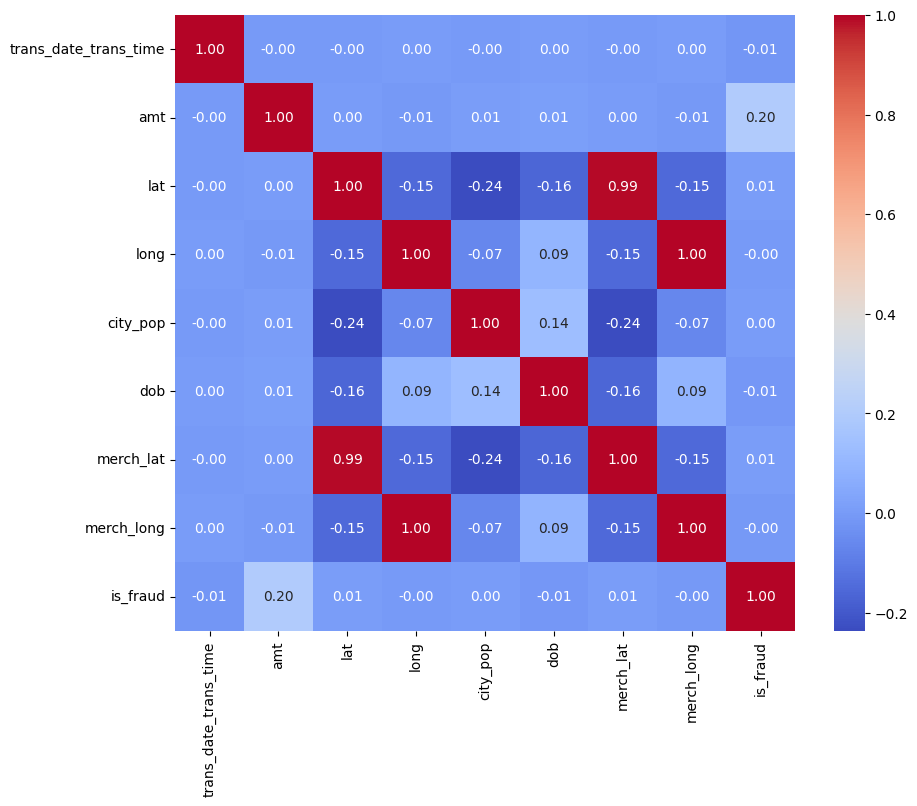

In [10]:
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [11]:
num_cols= df.select_dtypes(exclude = 'object').drop('is_fraud',axis=1).columns

print("--- Resumen de Outliers ---")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    perc = (len(outliers) / len(df)) * 100
    print(f"{col}: {len(outliers)} registros ({perc:.2f}%)")

--- Resumen de Outliers ---
trans_date_trans_time: 0 registros (0.00%)
amt: 18043 registros (5.31%)
lat: 6612 registros (1.95%)
long: 6598 registros (1.94%)
city_pop: 65168 registros (19.19%)
dob: 0 registros (0.00%)
merch_lat: 6612 registros (1.95%)
merch_long: 6598 registros (1.94%)


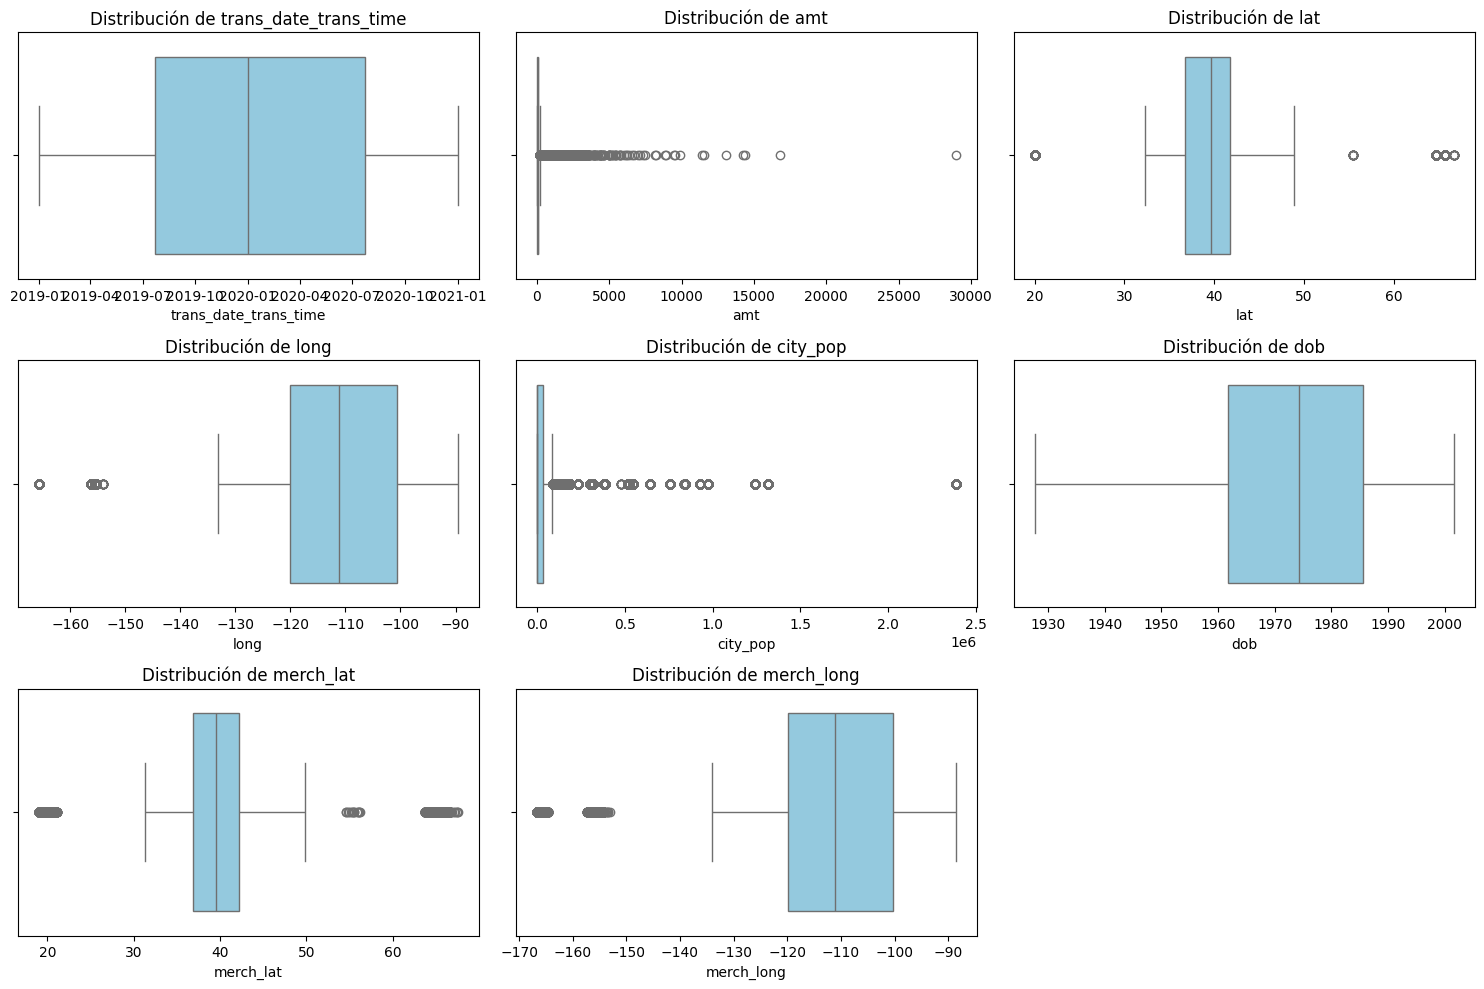

In [12]:
# 2. Visualización mediante Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [17]:
df_clean = df[(df['lat'] <52) & (df['lat'] > 25) &
              (df['city_pop'] < 1000000) & (df['city_pop'] > 0) &
              (df['amt'] <4000) & (df['amt'] > 0)&
              (df['long'] > -140)
              ]

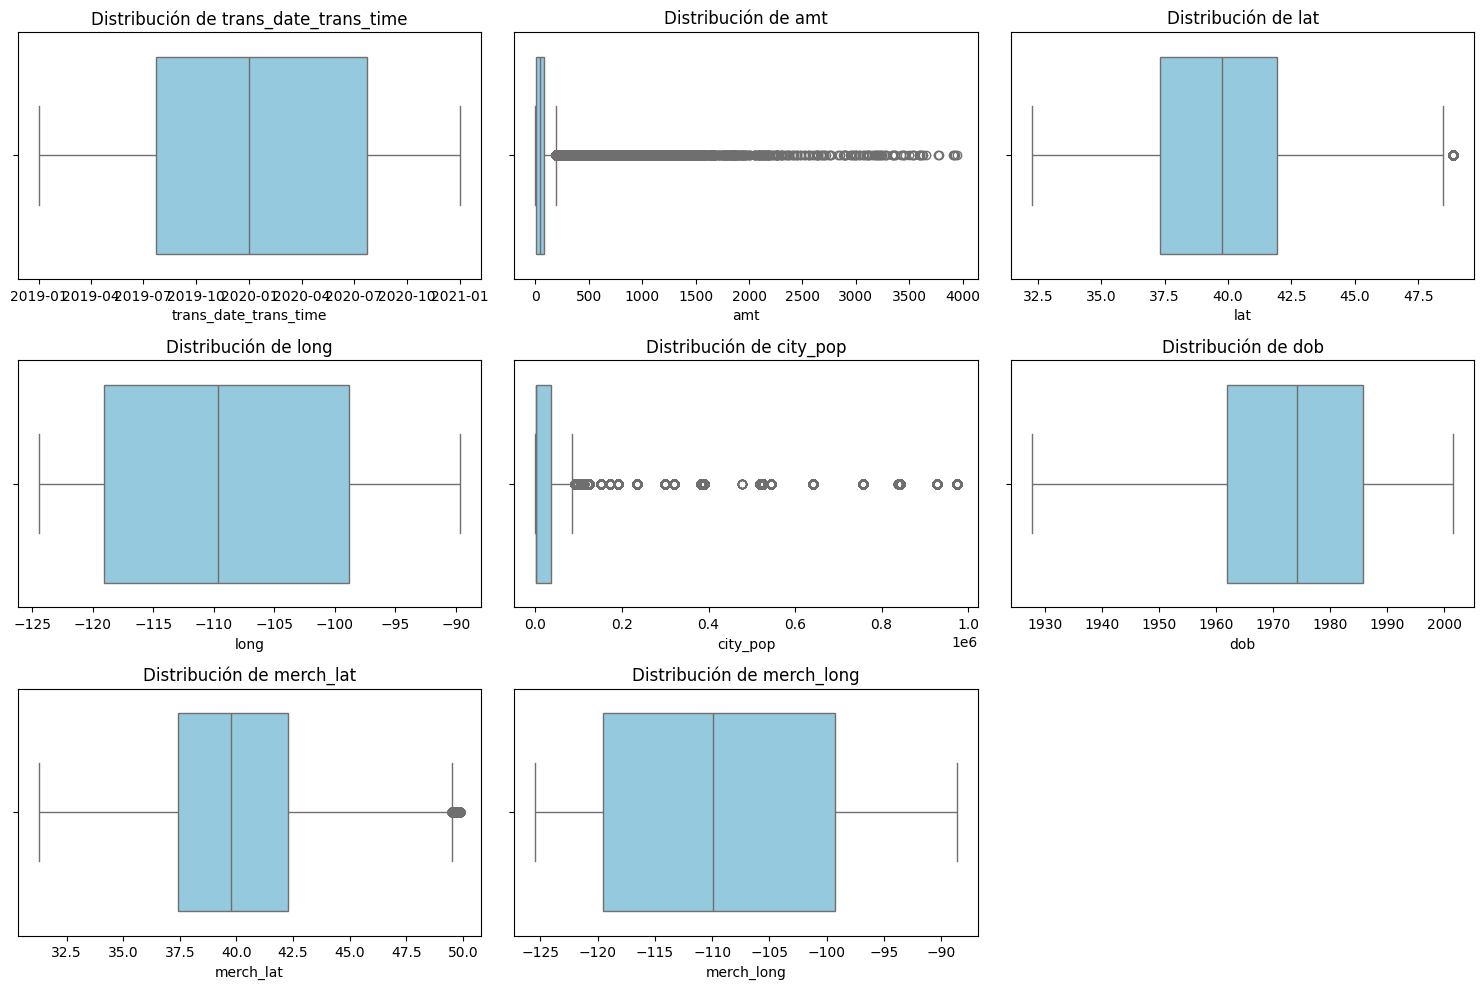

In [18]:
num_cols= df_clean.select_dtypes(exclude = 'object').drop('is_fraud',axis=1).columns

# 2. Visualización mediante Boxplots
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df_clean[col], color='skyblue')
    plt.title(f'Distribución de {col}')

plt.tight_layout()
plt.show()

In [19]:
# Análisis de cardinalidad
columnas_categoricas = df.select_dtypes(include=['object']).columns

# Creamos un resumen de valores únicos
analisis_cardinalidad = pd.DataFrame({
    'Variable': columnas_categoricas,
    'Valores Únicos': [df[col].nunique() for col in columnas_categoricas]
}).sort_values(by='Valores Únicos', ascending=False)

print("--- Resumen de Cardinalidad ---")
print(analisis_cardinalidad)

--- Resumen de Cardinalidad ---
    Variable  Valores Únicos
5  trans_num          339607
0   merchant             693
2       city             176
4        job             163
1   category              14
3      state              13


In [20]:
# 1. Convertir las columnas a formato datetime (si no se ha hecho antes)
df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
df_clean['dob'] = pd.to_datetime(df_clean['dob'])

# 2. Calcular la edad (Age)
# Restamos la fecha de transacción de la fecha de nacimiento
df_clean['age'] = (df_clean['trans_date_trans_time'] - df_clean['dob']).dt.days // 365

# 3. Extraer información temporal de la transacción
# La hora es vital para detectar fraudes nocturnos
df_clean['hour'] = df_clean['trans_date_trans_time'].dt.hour
# El día de la semana (0=Lunes, 6=Domingo)
df_clean['day_of_week'] = df_clean['trans_date_trans_time'].dt.dayofweek

# 4. Verificamos que las nuevas columnas existan
print("Nuevas variables creadas:")
print(df_clean[['trans_date_trans_time', 'dob', 'age', 'hour', 'day_of_week']].head())

Nuevas variables creadas:
  trans_date_trans_time        dob  age  hour  day_of_week
0   2019-01-01 00:00:44 1978-06-21   40     0            1
1   2019-01-01 00:00:51 1962-01-19   56     0            1
2   2019-01-01 00:07:27 1945-12-21   73     0            1
3   2019-01-01 00:09:03 1967-08-30   51     0            1
4   2019-01-01 00:21:32 1967-08-02   51     0            1


C:\Users\User\AppData\Local\Temp\ipykernel_12792\1069552002.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['trans_date_trans_time'] = pd.to_datetime(df_clean['trans_date_trans_time'])
C:\Users\User\AppData\Local\Temp\ipykernel_12792\1069552002.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['dob'] = pd.to_datetime(df_clean['dob'])
C:\Users\User\AppData\Local\Temp\ipykernel_12792\1069552002.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataF

In [21]:
from sklearn.preprocessing import LabelEncoder

# 1. Creamos el DataFrame final para el modelo
df_model = df_clean.copy()

# 2. Definimos qué columnas vamos a usar (Features)
# Incluimos las numéricas originales y las nuevas que creasteis
features_to_use = [
    'amt', 'lat', 'long', 'city_pop', 'merch_lat', 'merch_long', 
    'age', 'hour', 'day_of_week', 'category', 'state', 'job'
]

# 3. Aplicamos Label Encoding a TODAS las que sigan siendo 'object' (texto)
le = LabelEncoder()
for col in features_to_use:
    if df_model[col].dtype == 'object':
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        print(f"Variable '{col}' codificada.")

# 4. Definimos X (características) e y (objetivo)
X = df_model[features_to_use]
y = df_model['is_fraud']

print("\n--- TODO CODIFICADO ---")
print(X.info()) # Veréis que ahora todo es int o float

Variable 'category' codificada.
Variable 'state' codificada.
Variable 'job' codificada.

--- TODO CODIFICADO ---
<class 'pandas.core.frame.DataFrame'>
Index: 321241 entries, 0 to 339606
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   amt          321241 non-null  float64
 1   lat          321241 non-null  float64
 2   long         321241 non-null  float64
 3   city_pop     321241 non-null  int64  
 4   merch_lat    321241 non-null  float64
 5   merch_long   321241 non-null  float64
 6   age          321241 non-null  int64  
 7   hour         321241 non-null  int32  
 8   day_of_week  321241 non-null  int32  
 9   category     321241 non-null  int64  
 10  state        321241 non-null  int64  
 11  job          321241 non-null  int64  
dtypes: float64(5), int32(2), int64(5)
memory usage: 29.4 MB
None


In [31]:
# 1. Realizamos la división pasando el DataFrame completo (df_model)
# Esto nos devuelve exactamente dos partes: una para entrenamiento y otra para prueba
df_train, df_test = train_test_split(
    df_model, 
    test_size=0.20, 
    random_state=42, 
    stratify=df_model['is_fraud'] # Mantenemos la proporción de fraude 
)

# 2. Verificamos que se haya dividido bien
print(f"Registros en Train: {len(df_train)}")
print(f"Registros en Test: {len(df_test)}")


# 3. Guardamos en la carpeta de tu repositorio (como querías antes)


df_train.to_csv('../data/train.csv', index=False)
df_test.to_csv('../data/test.csv', index=False)

Registros en Train: 256992
Registros en Test: 64249
